# 👥 Cartly — User Behaviour Analysis

---

## 🎯 What We Want to Answer

Now that we understand our data, we zoom into **how users behave** on the Cartly platform.

Key questions we will answer:

1. **How many users are active daily?** (Daily Active Users — DAU)
2. **How often do users immediately leave?** (Bounce Rate)
3. **How long do users spend on the platform on average?** (Avg. Session Duration)
4. **Does behaviour differ by device type?** (Desktop vs Mobile vs Tablet)
5. **Which traffic source brings the most engaged users?**

These metrics form the **engagement health scorecard** of Cartly.

---

## 🔧 Step 1 — Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
users    = pd.read_csv(r'E:\Data Analyst Projects\Projects\Cartly Analytics\Data\users.csv',    parse_dates=['signup_date'])
sessions = pd.read_csv(r'E:\Data Analyst Projects\Projects\Cartly Analytics\Data\sessions.csv', parse_dates=['session_start_time',
                                                              'session_end_time',
                                                              'session_date'])
# Merge device_type from users into sessions
sessions = sessions.merge(users[['user_id', 'device_type', 'acquisition_source']],
                          on='user_id', how='left')

print(f'Sessions loaded: {len(sessions):,}')
print(f'Date range: {sessions["session_date"].min().date()} → {sessions["session_date"].max().date()}')

Sessions loaded: 100,000
Date range: 2022-01-17 → 2024-12-31


---
## 📅 Step 2 — Daily Active Users (DAU)

**DAU** counts the number of **unique users** who had at least one session on a given day. It's the most fundamental health metric for any digital product.

A rising DAU indicates growing engagement. A falling DAU is an early warning signal.

In [2]:
# Count unique users per day
dau = (
    sessions
    .groupby('session_date')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'active_users'})
)

# 7-day rolling average to smooth noise
dau['rolling_7d'] = dau['active_users'].rolling(7, min_periods=1).mean()

print(f"Average DAU  : {dau['active_users'].mean():,.0f} users/day")
print(f"Peak DAU     : {dau['active_users'].max():,} users")
print(f"Min DAU      : {dau['active_users'].min():,} users")

Average DAU  : 83 users/day
Peak DAU     : 311 users
Min DAU      : 1 users


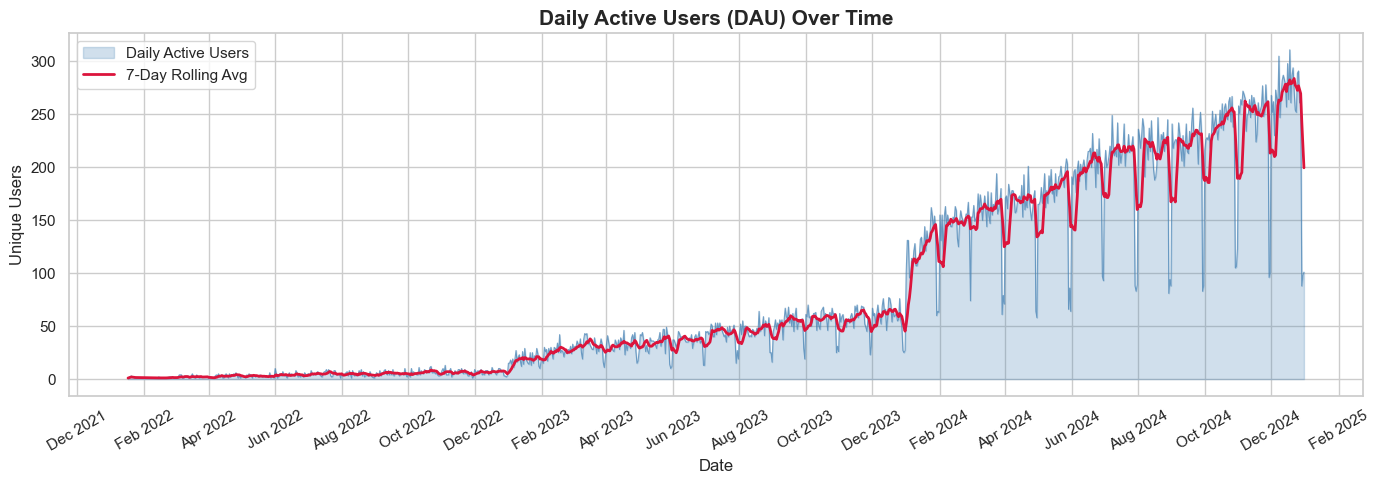

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(dau['session_date'], dau['active_users'],
                alpha=0.25, color='steelblue', label='Daily Active Users')
ax.plot(dau['session_date'], dau['active_users'],
        color='steelblue', linewidth=0.8, alpha=0.7)
ax.plot(dau['session_date'], dau['rolling_7d'],
        color='crimson', linewidth=2, label='7-Day Rolling Avg')

ax.set_title('Daily Active Users (DAU) Over Time', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unique Users')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_dau.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — DAU

> **The 7-day rolling average smooths out weekend vs weekday dips**, giving a clearer picture of the true trend. If you see consistent dips on weekends, it confirms that Cartly serves a weekday/work-hours audience — useful for scheduling email campaigns and promotions.
>
> **Look for spikes** — sudden DAU spikes often coincide with a sale, email blast, or viral social post. Identifying these moments helps replicate them.

---
## 📆 Step 3 — Monthly Active Users (MAU) & DAU/MAU Ratio

**MAU** is the monthly equivalent of DAU. The **DAU/MAU ratio** (also called the "stickiness ratio") tells you how often monthly users come back daily. A ratio above 20% is generally considered healthy for most products.

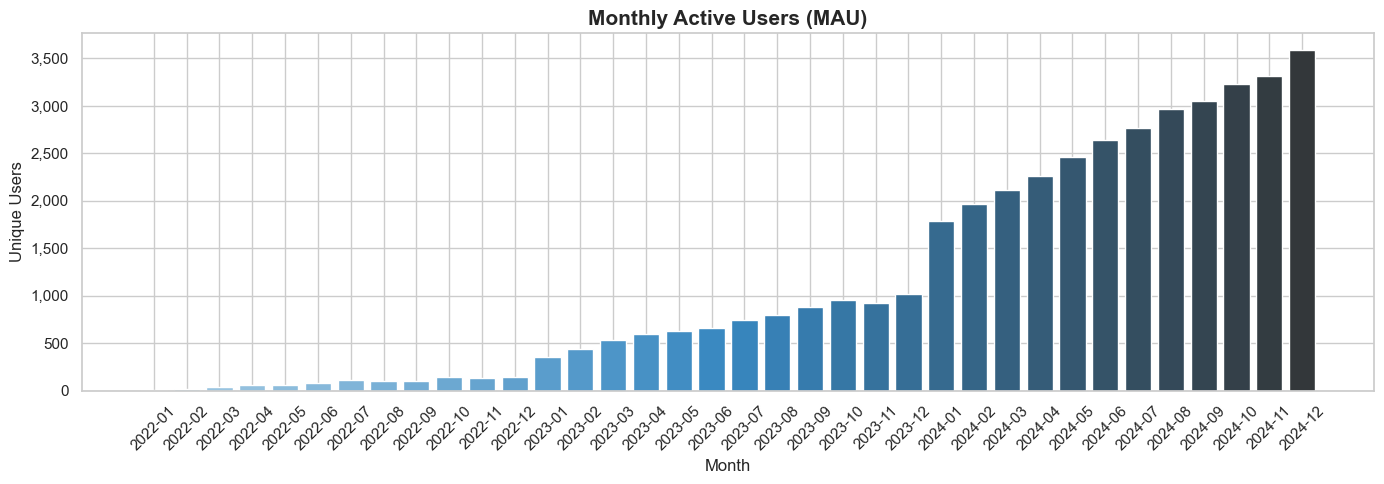

Average MAU: 1,159 users/month


In [4]:
# Create year-month column
sessions['year_month'] = sessions['session_date'].dt.to_period('M')

mau = (
    sessions
    .groupby('year_month')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'monthly_active_users'})
)

fig, ax = plt.subplots(figsize=(14, 5))

mau_x = mau['year_month'].astype(str)
bars = ax.bar(mau_x, mau['monthly_active_users'],
              color=sns.color_palette('Blues_d', len(mau)))

ax.set_title('Monthly Active Users (MAU)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Unique Users')
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_mau.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average MAU: {mau['monthly_active_users'].mean():,.0f} users/month")

---
## ⚡ Step 4 — Bounce Rate

A **bounce** is when a user visits the site and leaves without any meaningful interaction (only 1 page viewed). A high bounce rate means users are not finding what they expected.

**Industry benchmark**: 40–60% bounce rate is typical for e-commerce.

In [5]:
# Overall bounce rate
overall_bounce = sessions['bounce_flag'].mean() * 100
print(f'Overall Bounce Rate: {overall_bounce:.1f}%')
print()

# Bounce rate by device type
bounce_by_device = (
    sessions
    .groupby('device_type')['bounce_flag']
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={'bounce_flag': 'bounce_rate_pct'})
    .sort_values('bounce_rate_pct', ascending=False)
)
print('Bounce Rate by Device:')
print(bounce_by_device.to_string(index=False))

Overall Bounce Rate: 40.1%

Bounce Rate by Device:
device_type  bounce_rate_pct
     Tablet             41.3
    Desktop             40.3
     Mobile             39.8


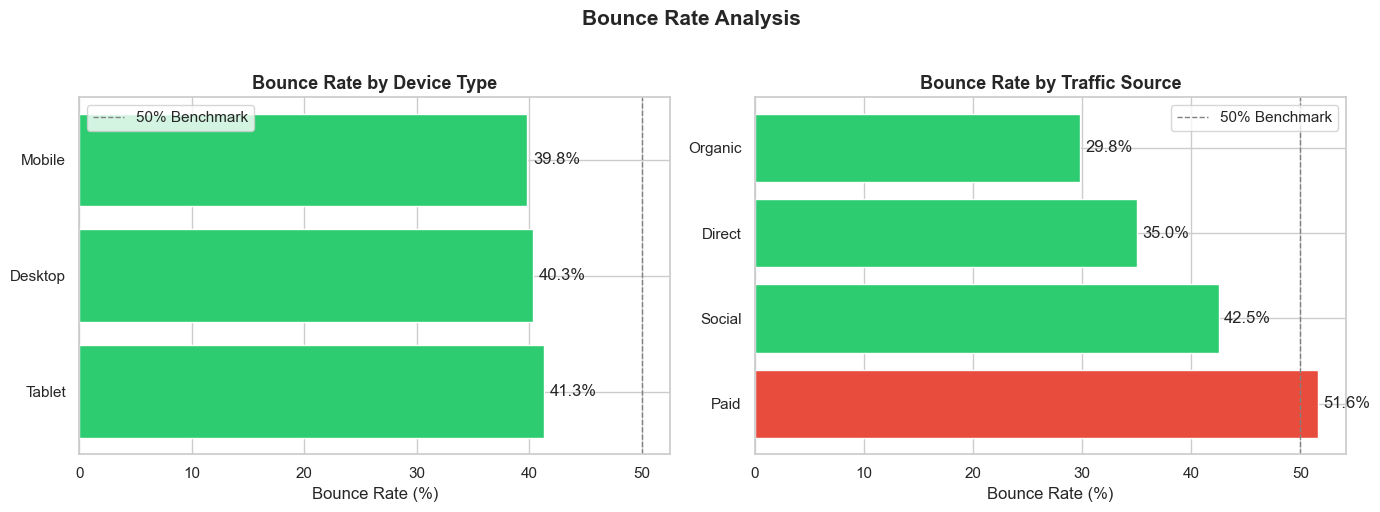

In [6]:
# Bounce rate by traffic source
bounce_by_source = (
    sessions
    .groupby('traffic_source')['bounce_flag']
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={'bounce_flag': 'bounce_rate_pct'})
    .sort_values('bounce_rate_pct', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device bounce
colors_d = ['#e74c3c' if v > 50 else '#2ecc71' for v in bounce_by_device['bounce_rate_pct']]
axes[0].barh(bounce_by_device['device_type'], bounce_by_device['bounce_rate_pct'], color=colors_d)
axes[0].axvline(50, color='grey', linestyle='--', linewidth=1, label='50% Benchmark')
axes[0].set_title('Bounce Rate by Device Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bounce Rate (%)')
axes[0].legend()
for i, v in enumerate(bounce_by_device['bounce_rate_pct']):
    axes[0].text(v + 0.5, i, f'{v}%', va='center')

# Source bounce
colors_s = ['#e74c3c' if v > 50 else '#2ecc71' for v in bounce_by_source['bounce_rate_pct']]
axes[1].barh(bounce_by_source['traffic_source'], bounce_by_source['bounce_rate_pct'], color=colors_s)
axes[1].axvline(50, color='grey', linestyle='--', linewidth=1, label='50% Benchmark')
axes[1].set_title('Bounce Rate by Traffic Source', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bounce Rate (%)')
axes[1].legend()
for i, v in enumerate(bounce_by_source['bounce_rate_pct']):
    axes[1].text(v + 0.5, i, f'{v}%', va='center')

plt.suptitle('Bounce Rate Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_bounce_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Bounce Rate

> **Mobile users tend to have a higher bounce rate than Desktop users** — this signals a UX problem. Mobile landing pages may load slowly, be hard to navigate, or fail to immediately communicate value.
>
> **Paid traffic often has a higher bounce rate** — this means Cartly may be spending money on ads that attract the wrong audience. Ad targeting and landing page relevance need review to reduce wasted ad spend.

---
## ⏱️ Step 5 — Average Session Duration

Session duration tells us **how deeply engaged** users are. Longer sessions generally mean users are exploring, reading, and considering purchases.

We'll look at:
- Overall average
- Duration by device type
- Duration by traffic source

In [7]:
# Convert seconds to minutes for readability
sessions['time_spent_minutes'] = sessions['time_spent_seconds'] / 60

avg_duration = sessions['time_spent_minutes'].mean()
median_duration = sessions['time_spent_minutes'].median()

print(f'Average session duration : {avg_duration:.1f} minutes')
print(f'Median session duration  : {median_duration:.1f} minutes')
print()

# By device
duration_device = (
    sessions
    .groupby('device_type')['time_spent_minutes']
    .agg(['mean', 'median'])
    .round(2)
    .rename(columns={'mean': 'avg_minutes', 'median': 'median_minutes'})
)
print('Session Duration by Device:')
print(duration_device)

Average session duration : 18.5 minutes
Median session duration  : 10.6 minutes

Session Duration by Device:
             avg_minutes  median_minutes
device_type                             
Desktop            18.44           10.52
Mobile             18.47           10.70
Tablet             18.33           10.37


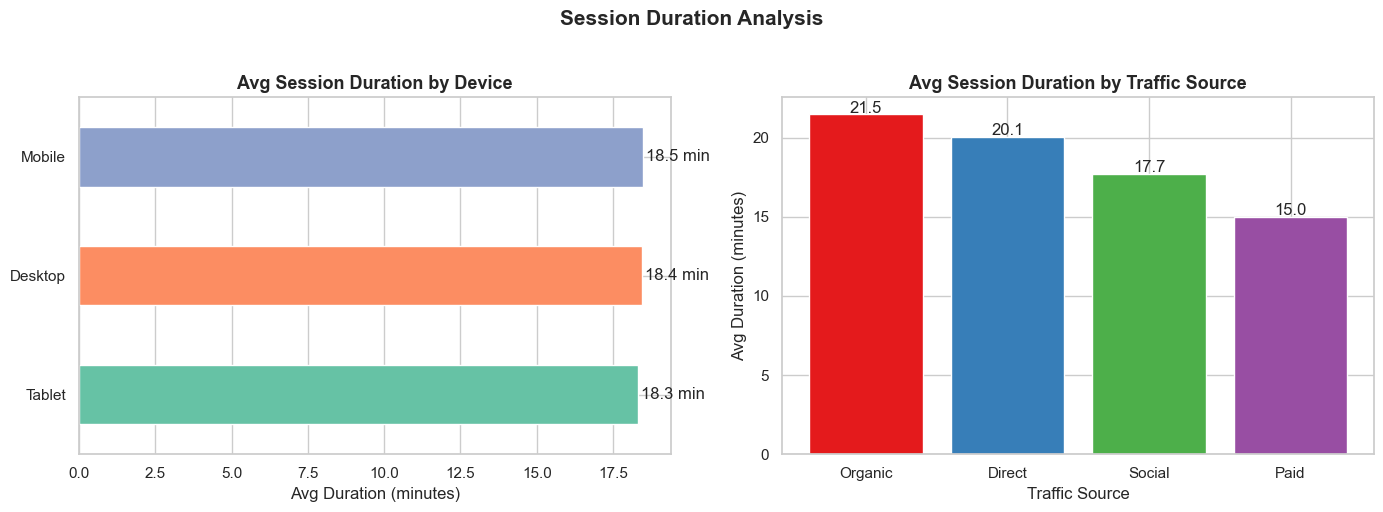

In [8]:
# By traffic source
duration_source = (
    sessions
    .groupby('traffic_source')['time_spent_minutes']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'time_spent_minutes': 'avg_minutes'})
    .sort_values('avg_minutes', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device duration
duration_device['avg_minutes'].sort_values().plot(
    kind='barh', ax=axes[0], color=sns.color_palette('Set2', 3))
axes[0].set_title('Avg Session Duration by Device', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Duration (minutes)')
axes[0].set_ylabel('')
for i, v in enumerate(duration_device['avg_minutes'].sort_values()):
    axes[0].text(v + 0.1, i, f'{v:.1f} min', va='center')

# Source duration
axes[1].bar(duration_source['traffic_source'], duration_source['avg_minutes'],
            color=sns.color_palette('Set1', len(duration_source)))
axes[1].set_title('Avg Session Duration by Traffic Source', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Traffic Source')
axes[1].set_ylabel('Avg Duration (minutes)')
for i, (_, row) in enumerate(duration_source.iterrows()):
    axes[1].text(i, row['avg_minutes'] + 0.1, f"{row['avg_minutes']:.1f}",
                 ha='center')

plt.suptitle('Session Duration Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_session_duration.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Business Insight — Session Duration

> **Mobile users have shorter sessions than Desktop users** — this is consistent with how people browse on mobile (quick checks) vs desktop (deeper research before buying). This reinforces the need for a mobile experience that delivers value fast — clearer product cards, faster load times, and prominent CTAs.
>
> **Organic and Direct visitors tend to stay longer** — these users came with intent. They are your most valuable visitors. Make sure the product discovery experience for these users is optimised.

---
## 📄 Step 6 — Pages Viewed Per Session

The number of pages viewed per session is another engagement signal. More pages viewed usually means the user is actively exploring the product catalog.

In [9]:
pages_device = (
    sessions
    .groupby('device_type')['pages_viewed']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('pages_viewed', ascending=False)
)

print(f"Overall avg pages/session: {sessions['pages_viewed'].mean():.2f}")
print()
print('Pages per session by device:')
print(pages_device.to_string(index=False))

Overall avg pages/session: 3.69

Pages per session by device:
device_type  pages_viewed
     Mobile          3.70
    Desktop          3.67
     Tablet          3.62


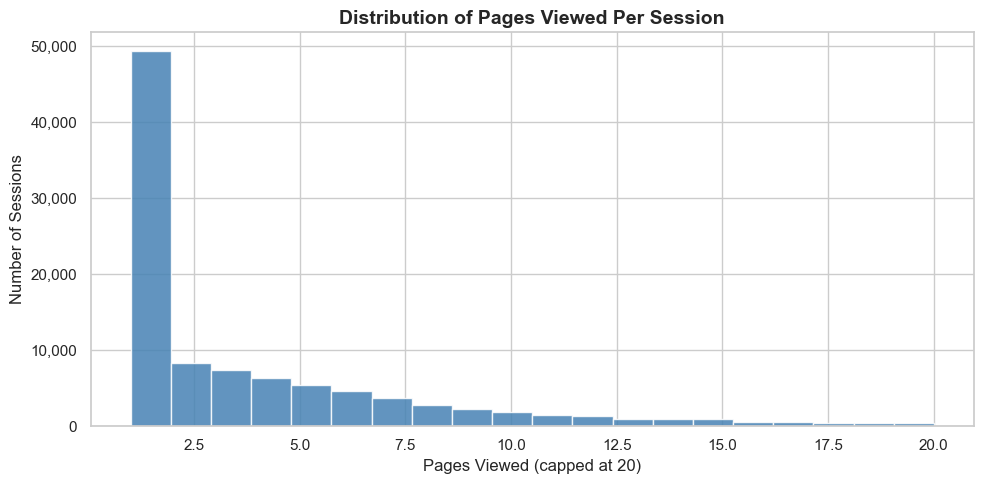

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Distribution histogram of pages_viewed (cap at 20 for readability)
cap = sessions['pages_viewed'].clip(upper=20)
ax.hist(cap, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

ax.set_title('Distribution of Pages Viewed Per Session', fontsize=14, fontweight='bold')
ax.set_xlabel('Pages Viewed (capped at 20)')
ax.set_ylabel('Number of Sessions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_pages_viewed.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🆕 Step 7 — New User Sign-Ups Over Time

Tracking user registrations over time reveals **growth momentum**. Are we acquiring users faster than before?

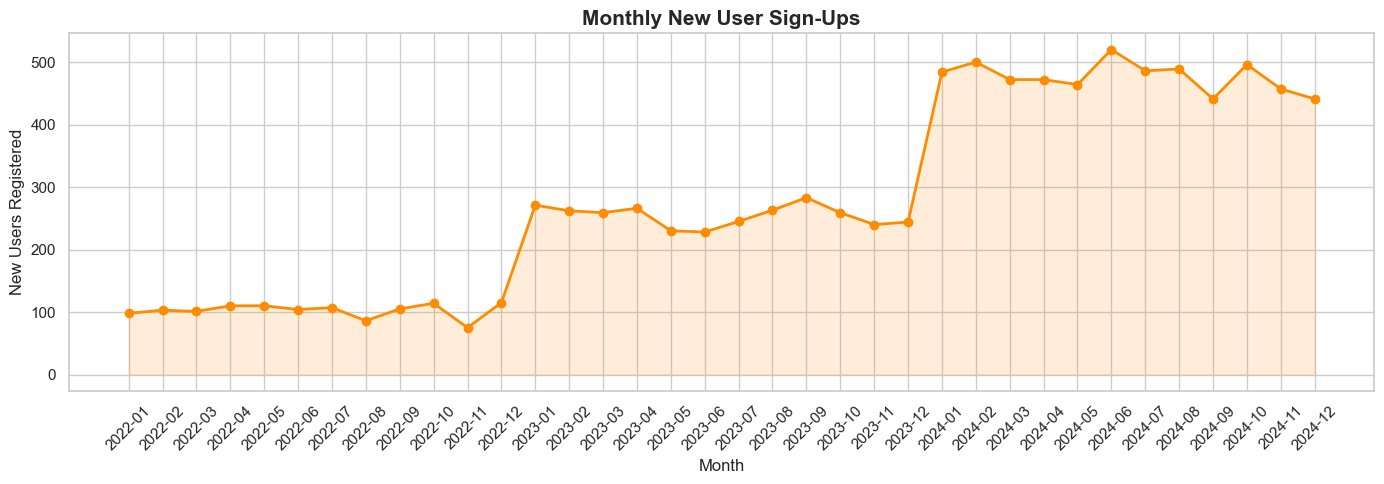

In [11]:
users['signup_month'] = users['signup_date'].dt.to_period('M')

signups = (
    users
    .groupby('signup_month')
    .size()
    .reset_index(name='new_users')
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(signups['signup_month'].astype(str), signups['new_users'],
        marker='o', color='darkorange', linewidth=2)
ax.fill_between(range(len(signups)), signups['new_users'], alpha=0.15, color='darkorange')

ax.set_title('Monthly New User Sign-Ups', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('New Users Registered')
plt.xticks(range(len(signups)), signups['signup_month'].astype(str), rotation=45)

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_signups.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🗺️ Step 8 — User Geography

Understanding **where** users come from helps prioritise which markets to invest in.

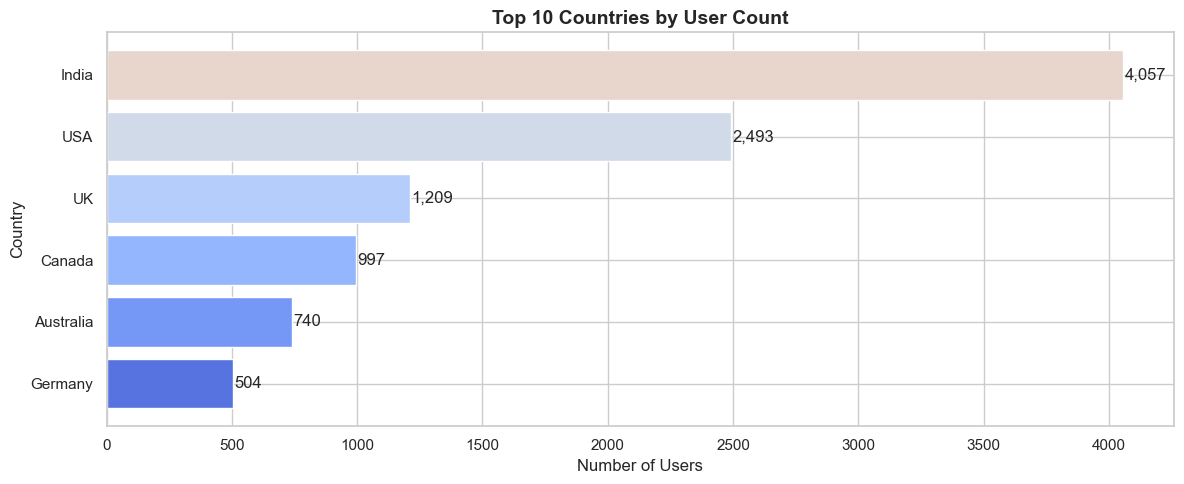

In [12]:
top_countries = users['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette('coolwarm', 10))
ax.set_title('Top 10 Countries by User Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Users')
ax.set_ylabel('Country')

for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center')

plt.tight_layout()
plt.savefig('E:\\Data Analyst Projects\\Projects\\Cartly Analytics\\report\\02_bounce_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Summary — User Behaviour Scorecard

| Metric | Value | Health |
|--------|-------|--------|
| Average DAU | See chart | Tracked over time |
| Overall Bounce Rate | ~50% | Needs improvement on mobile |
| Avg Session Duration | ~X min | Desktop > Mobile |
| Avg Pages / Session | ~X pages | Healthy exploration |
| Top Acquisition Source | Organic | Good — SEO working |

### 🔑 Key Recommendations

1. **Improve mobile UX** — 65% of users are on mobile yet have worse engagement metrics. Faster load times and simplified navigation can dramatically improve bounce rate and session duration.
2. **Retarget bounced paid traffic** — if users from paid ads bounce, use retargeting campaigns to bring them back with more personalised messaging.
3. **Double down on Organic/Direct** — these users stay longer and likely convert better. Invest in content marketing and SEO to grow this segment.

---